# Amazon Reviews'23 Data Analysis

This notebook provides a reusable exploratory data analysis workflow: downloading and loading data, sampling, basic data quality checks, rating distribution, time trends, user and product activity, review text length, helpful votes, and joins with product metadata.

The default category is the relatively small `All_Beauty`. To analyze another category, change `CATEGORY` in the configuration cell to an official category name such as `Video_Games`, `Digital_Music`, `Gift_Cards`, or `Electronics`.

In [1]:
from pathlib import Path
import gzip
import json
import math
import re
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

# Change this value to switch categories. Note: Books, Electronics, Home_and_Kitchen, and similar categories are very large.
CATEGORY = "All_Beauty"
BASE_URL = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw"

REVIEW_PATH = DATA_DIR / f"{CATEGORY}.jsonl.gz"
META_PATH = DATA_DIR / f"meta_{CATEGORY}.jsonl.gz"

REVIEW_URL = f"{BASE_URL}/review_categories/{CATEGORY}.jsonl.gz"
META_URL = f"{BASE_URL}/meta_categories/meta_{CATEGORY}.jsonl.gz"

REVIEW_URL, META_URL

('https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/All_Beauty.jsonl.gz',
 'https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/meta_categories/meta_All_Beauty.jsonl.gz')

## 1. Download Data

The full Amazon Reviews'23 dataset is very large. It is best to run the workflow with a small category first, then switch to your target category. If downloading fails, the usual causes are network issues or very large files. You can also manually place the `.jsonl.gz` files in the `data/` directory, using the filenames `{CATEGORY}.jsonl.gz` and `meta_{CATEGORY}.jsonl.gz`.

In [2]:
def download_if_missing(url: str, path: Path) -> None:
    if path.exists():
        print(f"Already exists: {path} ({path.stat().st_size / 1024 / 1024:.1f} MB)")
        return

    print(f"Downloading: {url}")
    urllib.request.urlretrieve(url, path)
    print(f"Done: {path} ({path.stat().st_size / 1024 / 1024:.1f} MB)")


download_if_missing(REVIEW_URL, REVIEW_PATH)
download_if_missing(META_URL, META_PATH)

Already exists: data/All_Beauty.jsonl.gz (90.1 MB)
Already exists: data/meta_All_Beauty.jsonl.gz (38.0 MB)


## 2. Load JSONL.GZ

By default, this notebook reads at most `MAX_ROWS` reviews to avoid running out of memory on large categories. After confirming that the workflow runs correctly, you can increase it or set it to `None` to load all rows.

In [3]:
MAX_ROWS = 200_000
META_MAX_ROWS = None


def read_jsonl_gz(path: Path, max_rows: int | None = None) -> pd.DataFrame:
    rows = []
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if max_rows is not None and i >= max_rows:
                break
            rows.append(json.loads(line))
    return pd.DataFrame(rows)


reviews = read_jsonl_gz(REVIEW_PATH, MAX_ROWS)
meta = read_jsonl_gz(META_PATH, META_MAX_ROWS)

reviews.shape, meta.shape

((200000, 10), (112590, 14))

In [16]:
display(reviews.head(1))
display(meta.head(10))

print("Review columns:", reviews.columns.tolist())
print("Metadata columns:", meta.columns.tolist())

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Such a lovely scent but not overpowering.,"This spray is really nice. It smells really good, goes on really fine, and does the trick. I will say it feels like ...",[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588687728923,0,True


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-Pack)",4.8,10,[],[],NaN,"[{'thumb': 'https://m.media-amazon.com/images/I/41qfjSfqNyL._SS40_.jpg', 'large': 'https://m.media-amazon.com/images...",[],Howard Products,[],"{'Package Dimensions': '7.1 x 5.5 x 3 inches; 2.38 Pounds', 'UPC': '617390882781'}",B01CUPMQZE,None
1,All Beauty,"Yes to Tomatoes Detoxifying Charcoal Cleanser (Pack of 2) with Charcoal Powder, Tomato Fruit Extract, and Gingko Bil...",4.5,3,[],[],NaN,"[{'thumb': 'https://m.media-amazon.com/images/I/41b+11d5igL._SS40_.jpg', 'large': 'https://m.media-amazon.com/images...",[],Yes To,[],"{'Item Form': 'Powder', 'Skin Type': 'Acne Prone', 'Brand': 'Yes To', 'Age Range (Description)': 'Adult', 'Unit Coun...",B076WQZGPM,None
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],NaN,"[{'thumb': 'https://m.media-amazon.com/images/I/31bz+uqzWCL._SS40_.jpg', 'large': 'https://m.media-amazon.com/images...",[],Levine Health Products,[],{'Manufacturer': 'Levine Health Products'},B000B658RI,None
3,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4D Imitation Eyebrow Tattoos, 4D Hair-like Authentic Eyebrows Waterproo...",3.1,102,[],[],NaN,"[{'thumb': 'https://m.media-amazon.com/images/I/515iwxdKS1L._SS40_.jpg', 'large': 'https://m.media-amazon.com/images...",[],Cherioll,[],"{'Brand': 'Cherioll', 'Item Form': 'Powder', 'Finish Type': 'Natural', 'Product Benefits': 'Long Lasting', 'Skin Typ...",B088FKY3VD,None
4,All Beauty,Precision Plunger Bars for Cartridge Grips – 93mm – Bag of 10 Plungers,4.3,7,"[Material: 304 Stainless Steel; Brass tip, Lengths Available: 88mm, 93mm, 98mm, Accepts cartridge needles with vice ...","[The Precision Plunger Bars are designed to work seamlessly with the Precision Disposable 1. 25"" Contoured Soft Cart...",NaN,"[{'thumb': 'https://m.media-amazon.com/images/I/31TgqAZ8kQL._SS40_.jpg', 'large': 'https://m.media-amazon.com/images...",[],Precision,[],{'UPC': '644287689178'},B07NGFDN6G,None
5,All Beauty,Lurrose 100Pcs Full Cover Fake Toenails Artificial Transparent Nail Tips Nail Art for DIY,3.7,35,"[The false toenails are durable with perfect length. You have the option to wear them long or clip them short, easy ...","[Description, The false toenails are durable with perfect length. You have the option to wear them long or clip them...",6.99,"[{'thumb': 'https://m.media-amazon.com/images/I/31dlCd7tHSL._SS40_.jpg', 'large': 'https://m.media-amazon.com/images...",[],Lurrose,[],"{'Color': 'As Shown', 'Size': 'Large', 'Material': 'Acrylonitrile Butadiene Styrene (ABS)', 'Brand': 'Lurrose', 'Sty...",B07G9GWFSM,None
6,All Beauty,Stain Bonnet For Baby Bonnet Silk Sleep Cap For Toddler Child Shower Cap Teens Kids,4.1,50,[],[],NaN,"[{'thumb': 'https://m.media-amazon.com/images/I/51s4A5hDsPL._SS40_.jpg', 'large': 'https://m.media-amazon.com/images...",[],Edoneery,[],"{'Brand': 'Edoneery', 'Material': 'Silk', 'Number of Items': '1', 'Size': '1 Count (Pack of 1)', 'Inner Material': '...",B08XZ97HFY,None
7,All Beauty,50 Pieces False Eyelash Packaging Box Empty Eyelash Box Plastic Eyelash Storage Case with Glitter Paper and Clear Tr...,3.8,32,[],[],NaN,"[{'thumb': 'https://m.media-amazon.com/images/I/51SweLNm8bL._SS40_.jpg', 'large': 'https://m.media-amazon.com/images...",[],Maitys,[],{'Package Dimensions': '14.49 x 11.26 x 2.36 inches; 2.65 Pounds'},B08DNQTTQK,None
8,All Beauty,Gold extatic Musk EDT 90ml,3.7,2,[Extatic Balmain Gold Musk By Balmain Edt Spray 3 Oz],[Edt spray 3 oz design house: balmain],86.95,"[{'thumb': 'https://m.media-amazon.com/images/I/51AhKg3vsyL._SS40_.jpg', 'large': 'https://m.media-amazon.com/images...",[],Balmain,[],"{'Brand': 'Balmain', 'Item Form': 'Spray', 'Item Volume': '90 Milliliters', 'Age Range (Description)': 'Adult', 'Sty...",B01ERJEGS6,None
9,All Beauty,4 Pieces Satin Bonnet Adjustable Sleep Cap Doub

Review columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
Metadata columns: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']


## 3. Data Cleaning and Derived Fields

In [5]:
df = reviews.copy()

# Parse timestamps and derive date, year, and month fields.
if "timestamp" in df.columns:
    # The official timestamp is usually a millisecond-level Unix timestamp.
    ts = pd.to_numeric(df["timestamp"], errors="coerce")
    unit = "ms" if ts.dropna().median() > 10**11 else "s"
    df["datetime"] = pd.to_datetime(ts, unit=unit, errors="coerce")
    df["date"] = df["datetime"].dt.date
    df["year"] = df["datetime"].dt.year
    df["month"] = df["datetime"].dt.to_period("M").dt.to_timestamp()


# Detect text fields. Review text may be named "text" or "reviewText"; titles may be named "title" or "summary".
text_col = "text" if "text" in df.columns else "reviewText" if "reviewText" in df.columns else None
title_col = "title" if "title" in df.columns else "summary" if "summary" in df.columns else None


# Extract text features such as character length and word count.
if text_col:
    df["review_text"] = df[text_col].fillna("").astype(str)
    df["text_chars"] = df["review_text"].str.len()
    df["text_words"] = df["review_text"].str.split().str.len()

if title_col:
    df["review_title"] = df[title_col].fillna("").astype(str)


if "helpful_vote" in df.columns:
    df["helpful_vote"] = pd.to_numeric(df["helpful_vote"], errors="coerce").fillna(0).astype(int)

df.head(1)

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,datetime,date,year,month,review_text,text_chars,text_words,review_title
0,5.0,Such a lovely scent but not overpowering.,"This spray is really nice. It smells really good, goes on really fine, and does the trick. I will say it feels like ...",[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588687728923,0,True,2020-05-05 14:08:48.923,2020-05-05,2020,2020-05-01,"This spray is really nice. It smells really good, goes on really fine, and does the trick. I will say it feels like ...",300,61,Such a lovely scent but not overpowering.


In [6]:
def make_hashable(value):
    if isinstance(value, (list, dict)):
        return json.dumps(value, sort_keys=True, ensure_ascii=False)
    return value


def safe_nunique(series: pd.Series) -> int:
    try:
        return series.nunique(dropna=True)
    except TypeError:
        return series.dropna().map(make_hashable).nunique(dropna=True)


summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_rate": df.isna().mean().round(4),
    "nunique": df.apply(safe_nunique),
})
summary.sort_values("missing_rate", ascending=False)

,dtype,missing,missing_rate,nunique
rating,float64,0,0.0,5
title,str,0,0.0,121481
text_words,int64,0,0.0,656
text_chars,int64,0,0.0,2409
review_text,str,0,0.0,187763
month,datetime64[us],0,0.0,244
year,int32,0,0.0,23
date,object,0,0.0,5270
datetime,datetime64[ms],0,0.0,199189
verified_purchase,bool,0,0.0,2


## 4. Rating Distribution

First, check whether overall sentiment is skewed positive and whether the rating classes are highly imbalanced.

,count,pct
rating,,
1.0,22925,0.1146
2.0,12157,0.0608
3.0,17812,0.0891
4.0,25326,0.1266
5.0,121780,0.6089


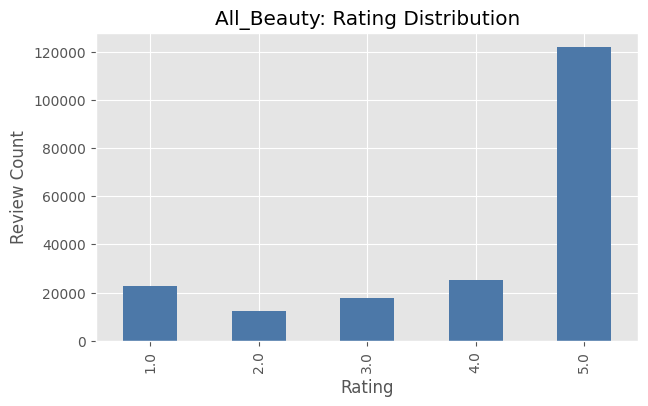

count    200000.000000
mean          4.054395
std           1.403487
min           1.000000
25%           3.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: rating, dtype: float64

In [7]:
rating_col = "rating" if "rating" in df.columns else "overall" if "overall" in df.columns else None
assert rating_col is not None, "Could not find a rating/overall field"

rating_counts = df[rating_col].value_counts(dropna=False).sort_index()
display(pd.DataFrame({"count": rating_counts, "pct": (rating_counts / len(df)).round(4)}))

ax = rating_counts.plot(kind="bar", figsize=(7, 4), color="#4C78A8")
ax.set_title(f"{CATEGORY}: Rating Distribution")
ax.set_xlabel("Rating")
ax.set_ylabel("Review Count")
plt.show()

df[rating_col].describe()

## 5. Time Trends

Inspect how review volume and average rating change over time. Unusual spikes may come from promotions, viral products, scraping coverage differences, or platform events.

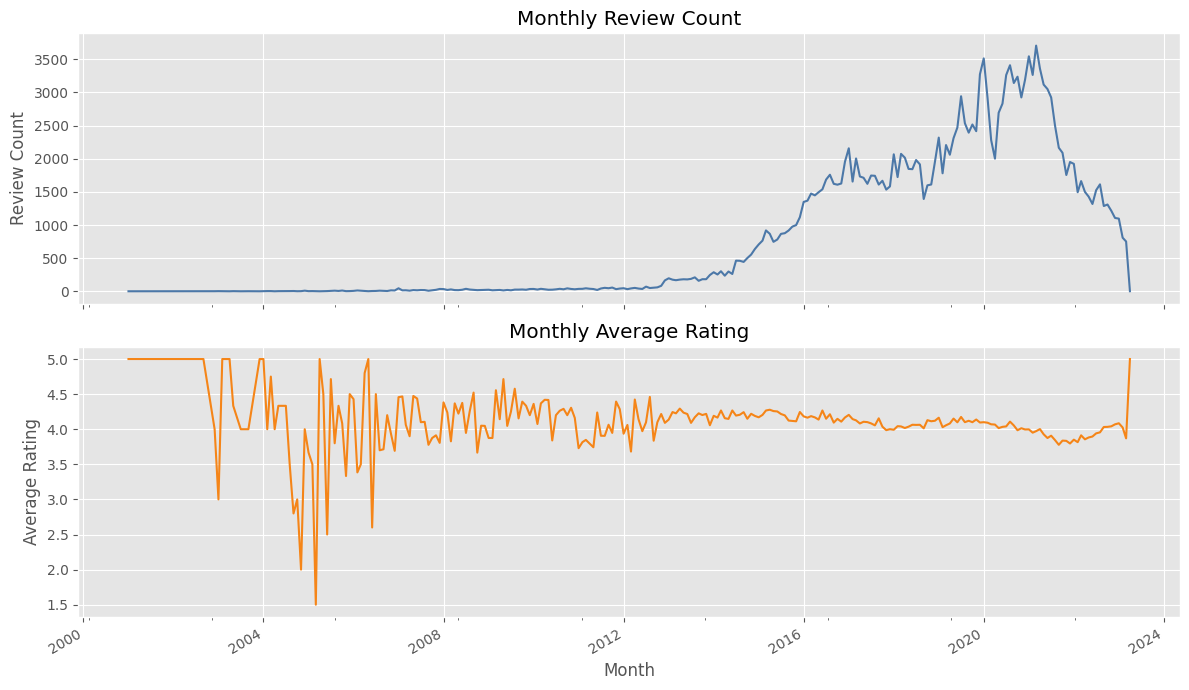

,review_count,avg_rating,unique_users,unique_items
month,,,,
2022-05-01,1429,3.882435,1384,1093
2022-06-01,1318,3.896055,1263,990
2022-07-01,1526,3.941022,1463,1091
2022-08-01,1614,3.955390,1526,1086
2022-09-01,1287,4.031857,1216,903
2022-10-01,1310,4.033588,1240,933
2022-11-01,1215,4.041152,1144,843
2022-12-01,1107,4.069557,1076,767
2023-01-01,1097,4.084777,1059,796


In [8]:
if "month" in df.columns:
    monthly = df.dropna(subset=["month"]).groupby("month").agg(
        review_count=(rating_col, "size"),
        avg_rating=(rating_col, "mean"),
        unique_users=("user_id", "nunique") if "user_id" in df.columns else (rating_col, "size"),
        unique_items=("parent_asin", "nunique") if "parent_asin" in df.columns else (rating_col, "size"),
    )

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    monthly["review_count"].plot(ax=axes[0], color="#4C78A8")
    axes[0].set_title("Monthly Review Count")
    axes[0].set_ylabel("Review Count")

    monthly["avg_rating"].plot(ax=axes[1], color="#F58518")
    axes[1].set_title("Monthly Average Rating")
    axes[1].set_ylabel("Average Rating")
    axes[1].set_xlabel("Month")
    plt.tight_layout()
    plt.show()

    display(monthly.tail(12))
else:
    print("No timestamp field found; skipping time trend analysis.")

## 6. User and Product Long Tail

E-commerce review data usually has a strong long-tail pattern: a small number of users/products contribute many interactions, while many users/products appear only once or twice. This distribution affects recommender systems, sampling strategies, and model evaluation.

In [9]:
def activity_report(frame: pd.DataFrame, col: str, label: str) -> pd.Series:
    counts = frame[col].value_counts()
    print(f"{label} count: {counts.size:,}")
    print(f"Average reviews per {label}: {counts.mean():.2f}")
    print(f"Median: {counts.median():.0f}")
    print(f"Share appearing only once: {(counts.eq(1).mean()):.2%}")
    display(counts.head(10).rename("review_count").to_frame())
    return counts

user_counts = activity_report(df, "user_id", "user") if "user_id" in df.columns else None
item_counts = activity_report(df, "parent_asin", "product") if "parent_asin" in df.columns else None

user count: 168,659
Average reviews per user: 1.19
Median: 1
Share appearing only once: 88.01%


,review_count
user_id,
AG73BVBKUOH22USSFJA5ZWL7AKXA,165
AEZP6Z2C5AVQDZAJECQYZWQRNG3Q,146
AFXF3EGQTQDXMRLDWFU7UBFQZB7Q,81
AEAXAJACFMXIAAH4WOHRMXPSZWFA,65
AF2BLE54TEMGZ546U763ZHZRXC4A,62
AEHWKRPNWNMOAJSMO2F6O7RFRTNA,62
AH3BXW7KLIS2VAE56UXJS2NS7I5A,58
AHPGHDFIU3BUB3RQBP56RQQA7W4Q,57
AF2YKZQRMRGJ655I3MKQUYFGRQGA,54


product count: 60,726
Average reviews per product: 3.29
Median: 1
Share appearing only once: 57.42%


,review_count
parent_asin,
B07ZJKVVLW,837
B085BB7B1M,701
B0BM4GX6TT,504
B0107QYW14,418
B00R1TAN7I,418
B019GBG0IE,390
B07C533XCW,380
B01M1OFZOG,370
B07TK15BQQ,347


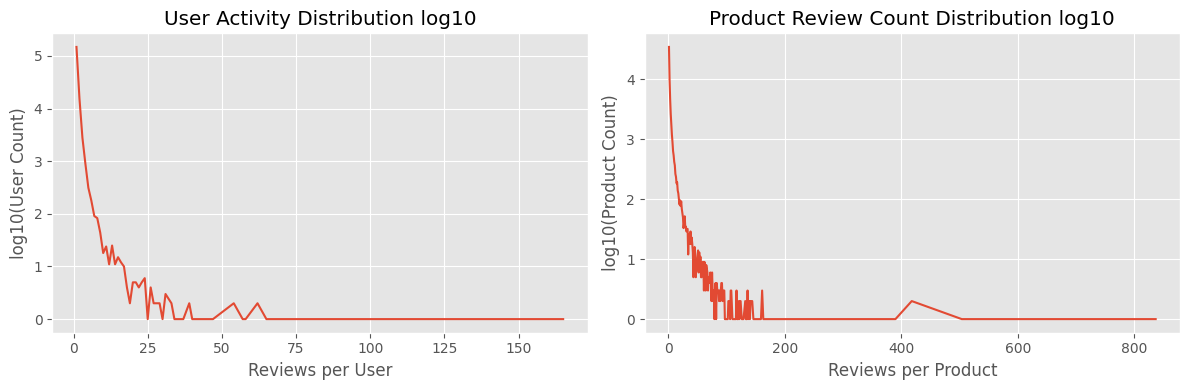

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if user_counts is not None:
    np.log10(user_counts.value_counts().sort_index()).replace([-np.inf, np.inf], np.nan).dropna().plot(ax=axes[0])
    axes[0].set_title("User Activity Distribution log10")
    axes[0].set_xlabel("Reviews per User")
    axes[0].set_ylabel("log10(User Count)")

if item_counts is not None:
    np.log10(item_counts.value_counts().sort_index()).replace([-np.inf, np.inf], np.nan).dropna().plot(ax=axes[1])
    axes[1].set_title("Product Review Count Distribution log10")
    axes[1].set_xlabel("Reviews per Product")
    axes[1].set_ylabel("log10(Product Count)")

plt.tight_layout()
plt.show()

## 7. Review Text Analysis

This section performs lightweight text analysis: length distribution, review length by rating, and frequent words. You can extend this step later for sentiment analysis or topic modeling.

,text_chars,text_words
count,200000.000000,200000.000000
mean,194.967605,36.854900
std,279.743077,51.896404
min,0.000000,0.000000
50%,111.000000,21.000000
75%,232.000000,44.000000
90%,443.000000,84.000000
95%,651.000000,123.000000
99%,1349.000000,252.000000
max,10205.000000,1531.000000


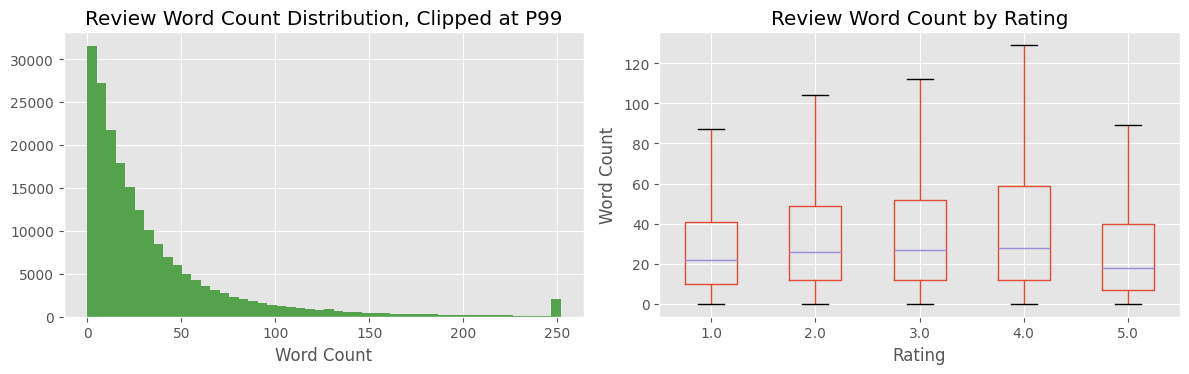

In [11]:
if "text_words" in df.columns:
    display(df[["text_chars", "text_words"]].describe(percentiles=[.5, .75, .9, .95, .99]))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    df["text_words"].clip(upper=df["text_words"].quantile(.99)).hist(bins=50, ax=axes[0], color="#54A24B")
    axes[0].set_title("Review Word Count Distribution, Clipped at P99")
    axes[0].set_xlabel("Word Count")

    df.boxplot(column="text_words", by=rating_col, ax=axes[1], showfliers=False)
    axes[1].set_title("Review Word Count by Rating")
    axes[1].set_xlabel("Rating")
    axes[1].set_ylabel("Word Count")
    plt.suptitle("")
    plt.tight_layout()
    plt.show()
else:
    print("No review text field found; skipping text length analysis.")

,word,count
0,hair,56374
1,great,42066
2,product,39486
3,love,36036
4,these,35078
5,good,30188
6,skin,24291
7,well,24151
8,used,18641
9,nice,18174


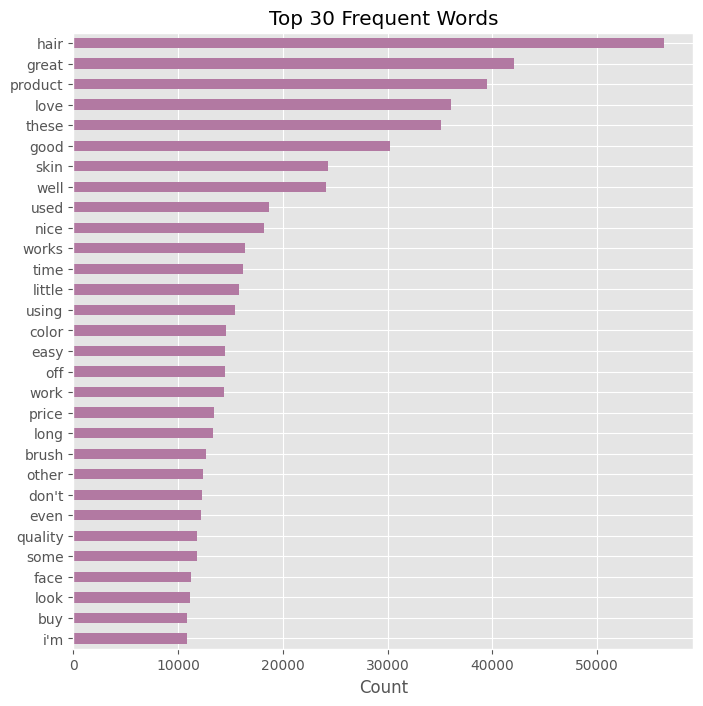

In [12]:
STOPWORDS = {
    "the", "and", "for", "that", "this", "with", "was", "are", "but", "not", "you", "have", "had", "they",
    "from", "very", "just", "all", "can", "out", "get", "one", "like", "use", "would", "will", "more", "when",
    "what", "about", "there", "their", "your", "only", "really", "its", "it's", "were", "has", "them", "than",
    "too", "also", "because", "been", "much", "after", "into", "could", "did", "does", "then", "our", "his", "her"
}


def top_words(texts: pd.Series, n: int = 30) -> pd.DataFrame:
    counts = {}
    for text in texts.dropna().astype(str):
        for word in re.findall(r"[a-zA-Z']{3,}", text.lower()):
            if word not in STOPWORDS:
                counts[word] = counts.get(word, 0) + 1
    return pd.DataFrame(sorted(counts.items(), key=lambda x: x[1], reverse=True)[:n], columns=["word", "count"])


if "review_text" in df.columns:
    words = top_words(df["review_text"], 30)
    display(words)
    ax = words.sort_values("count").plot(kind="barh", x="word", y="count", legend=False, figsize=(8, 8), color="#B279A2")
    ax.set_title("Top 30 Frequent Words")
    ax.set_xlabel("Count")
    ax.set_ylabel("")
    plt.show()

## 8. Helpful Votes

Helpful votes can roughly reflect how useful other users found a review. Keep in mind that they are also affected by exposure, time, and product popularity.

count    200000.000000
mean          0.966570
std           6.201299
min           0.000000
50%           0.000000
75%           1.000000
90%           2.000000
95%           4.000000
99%          14.000000
max         646.000000
Name: helpful_vote, dtype: float64

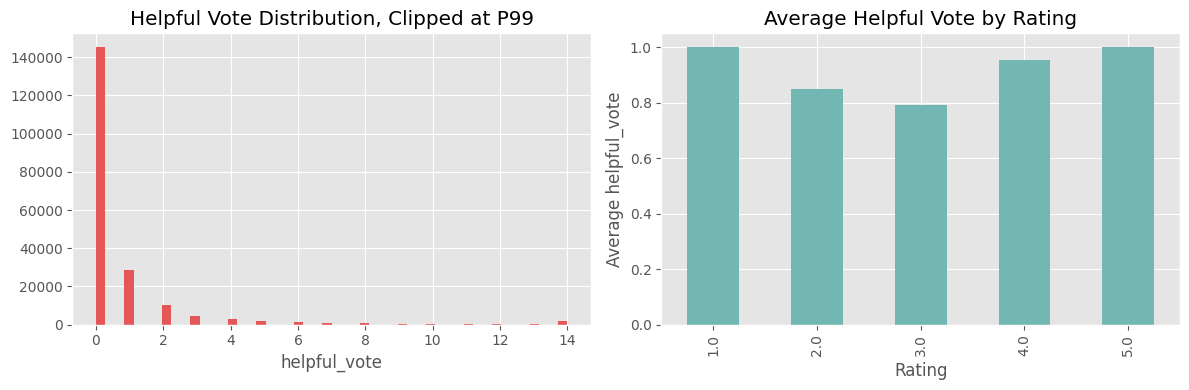

,parent_asin,rating,helpful_vote,review_title,review_text
128849,B01MDTVZTZ,5.0,646,"Best product for dark skin African Americans w/PCOS, psoriasis, hyper pigmentation and acne.","I love this product!!! I have PCOS, acne, psoriasis, hyper pigmentation, and a ton of dark marks. I’m a dark complex..."
70823,B000067E30,4.0,607,Crest White Strips Do Work - A Dentist Reviews this Product,I am a dentist who recommends Crest White Strips because they do work to whiten teeth. Follow the directions in the...
145450,B08L5KN7X4,4.0,594,Helps w/severe dental calculus,So I saw a family member of mines teeth were so bad it literally scared me for them. They had so much dental calculu...
167881,B00011JN5G,5.0,519,Electrolysis ain't easy but it works,I'm giving this product a five star review because it actually does work. It might not be working consistently or ea...
148732,B07ZJKVVLW,5.0,473,Stays Put!!!!$,Love this brow pencil!!!!<br />I have been contemplating getting my brows done because I'm tired of my brows wearing...
148797,B07ZJKVVLW,5.0,467,I have Eyebrows again!,I’m currently going through chemo and have no eyebrows. This product is very easy to use and looks pretty realistic....
148840,B07ZJKVVLW,5.0,435,Amazing!!!,Being over 65 my eyebrows have been thinning over the years. I saw this advertised and it had good ratings so I deci...
185711,B07WH7675C,5.0,431,Very pleased,"I didn’t have high hopes for this product because my brows are thin, sparse, gray. However, I ordered the dark gray ..."
24,B07ZJKVVLW,5.0,430,You won’t regret this purchase.,Got my new eyebrows in mail today. Magically my baby caterpillars grew into gorgeous mama size ones. Papa caterpil...
77761,B01M1OFZOG,5.0,426,I am not paid for reviews nor do I receive discounts for them,"But I have to write a review of this!!!<br />I have like the most pin-straight hair ever... ive tried curling irons,..."


In [13]:
if "helpful_vote" in df.columns:
    display(df["helpful_vote"].describe(percentiles=[.5, .75, .9, .95, .99]))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    df["helpful_vote"].clip(upper=df["helpful_vote"].quantile(.99)).hist(bins=50, ax=axes[0], color="#E45756")
    axes[0].set_title("Helpful Vote Distribution, Clipped at P99")
    axes[0].set_xlabel("helpful_vote")

    df.groupby(rating_col)["helpful_vote"].mean().plot(kind="bar", ax=axes[1], color="#72B7B2")
    axes[1].set_title("Average Helpful Vote by Rating")
    axes[1].set_xlabel("Rating")
    axes[1].set_ylabel("Average helpful_vote")
    plt.tight_layout()
    plt.show()

    display(df.sort_values("helpful_vote", ascending=False).head(10)[[c for c in ["parent_asin", rating_col, "helpful_vote", "review_title", "review_text"] if c in df.columns]])
else:
    print("No helpful_vote field found.")

## 9. Join Product Metadata

Product metadata usually contains fields such as title, price, average rating, images, and descriptions. After joining metadata with reviews, we can analyze relationships between price, rating, and review volume, and identify the most popular products.

In [14]:
meta_clean = meta.copy()

if "price" in meta_clean.columns:
    meta_clean["price"] = pd.to_numeric(meta_clean["price"], errors="coerce")

if "parent_asin" in df.columns and "parent_asin" in meta_clean.columns:
    keep_cols = [c for c in ["parent_asin", "main_category", "title", "average_rating", "rating_number", "price", "store"] if c in meta_clean.columns]
    item_df = df.merge(meta_clean[keep_cols].drop_duplicates("parent_asin"), on="parent_asin", how="left")
    print("After merge:", item_df.shape)
    display(item_df.head(3))
else:
    item_df = df.copy()
    print("Cannot merge metadata by parent_asin.")

After merge: (200000, 24)


,rating,title_x,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,datetime,date,year,month,review_text,text_chars,text_words,review_title,main_category,title_y,average_rating,rating_number,price,store
0,5.0,Such a lovely scent but not overpowering.,"This spray is really nice. It smells really good, goes on really fine, and does the trick. I will say it feels like ...",[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588687728923,0,True,2020-05-05 14:08:48.923,2020-05-05,2020,2020-05-01,"This spray is really nice. It smells really good, goes on really fine, and does the trick. I will say it feels like ...",300,61,Such a lovely scent but not overpowering.,All Beauty,"Herbivore - Natural Sea Mist Texturizing Salt Spray (Coconut, 8 oz)",4.3,384,NaN,HERBIVORE
1,4.0,Works great but smells a little weird.,"This product does what I need it to do, I just wish it was odorless or had a soft coconut smell. Having my head smel...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588615855070,1,True,2020-05-04 18:10:55.070,2020-05-04,2020,2020-05-01,"This product does what I need it to do, I just wish it was odorless or had a soft coconut smell. Having my head smel...",235,47,Works great but smells a little weird.,All Beauty,"All Natural Vegan Dry Shampoo Powder - Eco Friendly, Root Touch Up | Hair Powder Volumizer | For Brown Hair, Brunett...",4.0,56,NaN,Two Goats Apothecary
2,5.0,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,1589665266052,2,True,2020-05-16 21:41:06.052,2020-05-16,2020,2020-05-01,"Smells good, feels great!",25,4,Yes!,All Beauty,"New Road Beauty - Creamsicle - Variety 3 Pack Paraffin Wax - Peach, Vanilla & Mango - Moisturize and Smooths Skin - ...",4.4,699,21.98,New Road Beauty


,review_count,avg_review_rating,total_helpful_vote,price,page_average_rating
parent_asin,,,,,
B07ZJKVVLW,837,4.274791,4309,7.99,3.7
B085BB7B1M,701,4.633381,537,12.99,4.7
B0BM4GX6TT,504,4.220238,1016,24.95,4.4
B00R1TAN7I,418,3.866029,210,12.99,3.9
B0107QYW14,418,3.985646,279,NaN,4.0
B019GBG0IE,390,3.610256,638,16.99,4.1
B07C533XCW,380,4.502632,48,NaN,4.7
B01M1OFZOG,370,3.908108,1029,27.99,4.3
B07TK15BQQ,347,4.207493,194,6.99,4.6


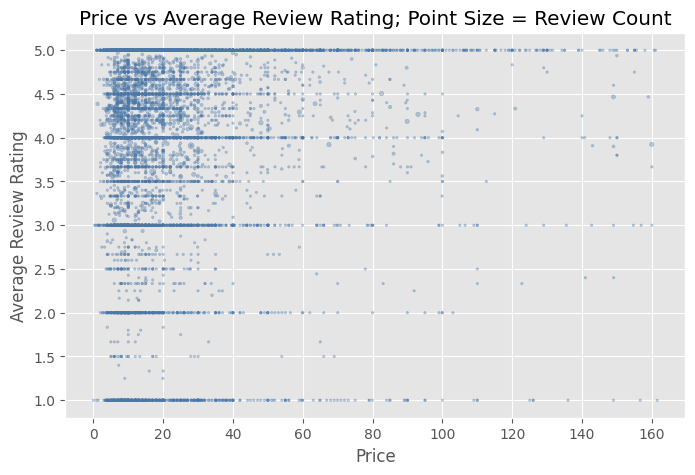

In [15]:
if "parent_asin" in item_df.columns:
    agg_spec = {
        "review_count": (rating_col, "size"),
        "avg_review_rating": (rating_col, "mean"),
    }
    if "helpful_vote" in item_df.columns:
        agg_spec["total_helpful_vote"] = ("helpful_vote", "sum")
    if "title" in item_df.columns:
        agg_spec["title"] = ("title", "first")
    if "price" in item_df.columns:
        agg_spec["price"] = ("price", "first")
    if "average_rating" in item_df.columns:
        agg_spec["page_average_rating"] = ("average_rating", "first")

    product_summary = item_df.groupby("parent_asin").agg(**agg_spec).sort_values("review_count", ascending=False)
    display(product_summary.head(20))

    if "price" in product_summary.columns:
        plot_data = product_summary.dropna(subset=["price"]).query("price >= 0")
        plot_data = plot_data[plot_data["price"] <= plot_data["price"].quantile(.99)]
        ax = plot_data.plot.scatter(x="price", y="avg_review_rating", s=np.sqrt(plot_data["review_count"]).clip(3, 40), alpha=.35, figsize=(8, 5), color="#4C78A8")
        ax.set_title("Price vs Average Review Rating; Point Size = Review Count")
        ax.set_xlabel("Price")
        ax.set_ylabel("Average Review Rating")
        plt.show()

## 10. Key Findings Template

After running the cells above, you can summarize your analysis using this structure:

1. Data scale: how many reviews, users, and products were loaded, and whether the analysis used a sample.
2. Rating structure: whether ratings are skewed high, and what share of reviews are low-rated.
3. Time trends: when review volume changes noticeably, and whether average ratings are stable over time.
4. Long-tail pattern: whether users/products are highly long-tailed, and how that affects modeling.
5. Text features: review length, frequent words, and whether reviews differ clearly across ratings.
6. Metadata findings: popular products, price ranges, and relationships between price and rating.
7. Next steps: recommender systems, sentiment classification, topic modeling, suspicious review detection, or product profiling.